Data (X, y)
   ↓ preprocess_y
SurrogateTrainer.fit
   ↓
Grid (compute_bounds → create_nd_grid → filter_grid)
   ↓
trainer.predict → mean
pairwise_distances → std
   ↓
compute_acquisition (PI/EI/UCB, xi/kappa)
   ↓
argmax → next_query, score
   ↓
log_query_candidate
   ↓
find_best_candidate → best

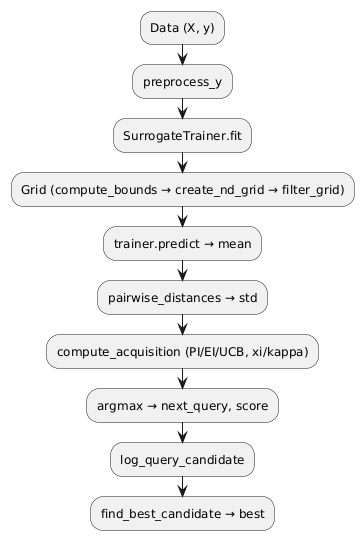

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import clear_output
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from scipy.stats import norm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn import svm
import math
import warnings
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

    hype-para-1  hype-para-2  hype-para-3  hype-para-4  hype-para-5  hype-para-6  hype-para-7  hype-para-8    output  source
41     0.121212     0.121212     0.000000     0.000000     0.363636     0.727273     0.484849     0.848484  9.609759  week-2
14     0.056447     0.065956     0.022929     0.038786     0.403935     0.801055     0.488307     0.893085  9.598482    file
42     0.043751     0.045306     0.045319     0.033695     0.337741     0.771663     0.496881     0.775992  9.587655  week-3
40     0.000000     0.125000     0.000000     0.000000     0.375000     0.750000     0.500000     0.875000  9.565800  week-1
26     0.192640     0.630677     0.416796     0.490529     0.796086     0.654567     0.276241     0.295518  9.344274    file
39     0.481245     0.102461     0.219486     0.677322     0.247509     0.244341     0.163825     0.715962  9.183005    file
22     0.145120     0.119328     0.420888     0.387609     0.155423     0.875172     0.510560     0.728611  9.141639    file


/var/folders/d6/s3jc1rb17y1411yjy8r6jlf80000gn/T/ipykernel_52230/923837372.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('tab10', len(other_cols))


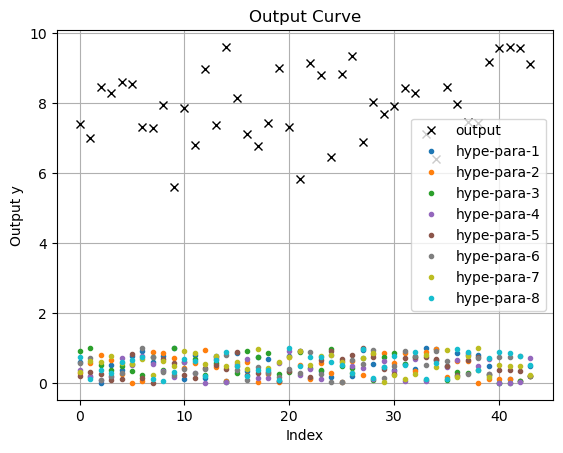

In [2]:
#Process data
%run data_handler.ipynb

In [3]:
#row_lowest_A = df_sorted.loc[df["radiation-reading"].idxmin()]
#print(row_lowest_A)
#df_sorted.drop(df["radiation-reading"].idxmin(), inplace=True)
# Preview
#print(df_sorted)
#plot_output_points(df_sorted, scale_factor=1.0, yield_scale_factor=1000, nan_marker='o')


In [4]:
X = inputs
y = outputs

In [5]:
%run ../common_functions.ipynb
# Initialize result collection
query_results = []


In [6]:
def sweep_hyperparameters_NNtrain(X, y,
                                  xi_values=[0.01, 0.1, 0.3],
                                  kappa_values=[1.0, 2.0, 3.0],
                                  grid_sizes=[50],
                                  methods=['PI', 'EI', 'UCB'],
                                  apply_scaling=False,
                                  filter_mode='gp'):
    """
    Sweep hyperparameters for query selection using a trained NN surrogate.
    Applies Bayesian optimisation acquisition functions (PI, EI, UCB).
    """
    global query_results
    query_results = []

    # Step 1: preprocess targets
    y_proc = preprocess_y(y, apply_scaling=apply_scaling)

    # Step 2: train NN surrogate once
    trainer = SurrogateTrainer(input_dim=X.shape[1], lr=1e-3, epochs=500)
    print("Epoch ", trainer.epochs)
    history = trainer.fit(X, y_proc, log_weights=True)
    # Plot loss curve
    plot_loss_curve(history)

    # Plot weight evolution (first layer mean)
    plot_weight_evolution(history, layer_name="model.0.weight", stat="mean")    

    # Step 3: loop over grid sizes
    for grid_size in grid_sizes:
        bounds = compute_bounds(X, margin=0.1)
        #X_grid_full = create_nd_grid(bounds, grid_size)
        X_grid_full = create_nd_grid(bounds, grid_size, downsample=True, stride=(len(bounds) + 6))
        X_grid_filtered = filter_grid(X, y_proc, X_grid_full, filter_mode=filter_mode)
        #X_grid_filtered = X_grid_full  #no filtering for NN surrogate

        if X_grid_filtered.shape[0] == 0:
            print(f"⚠️ Skipping grid_size={grid_size}, filter removed all points")
            continue

        # Step 4: predict surrogate outputs once per grid
        mean = trainer.predict(X_grid_filtered)
        
        # Step 5: uncertainty heuristic (distance to nearest training point)
        dist = pairwise_distances(X_grid_filtered, X)
        std = np.min(dist, axis=1)

        # Step 6: sweep acquisition hyperparameters
        for method in methods:
            if method in ['PI', 'EI']:
                for xi in xi_values:
                    acq_map = compute_acquisition(method, mean, std, y_proc, xi=xi)
                    best_index = np.argmax(acq_map)
                    next_query = X_grid_filtered[best_index]
                    score = acq_map[best_index]
                    log_query_candidate(method, xi, next_query, score)

            elif method == 'UCB':
                for kappa in kappa_values:
                    acq_map = compute_acquisition(method, mean, std, y_proc, kappa=kappa)
                    best_index = np.argmax(acq_map)
                    next_query = X_grid_filtered[best_index]
                    score = acq_map[best_index]
                    log_query_candidate(method, kappa, next_query, score)

    if not query_results:
        raise RuntimeError("No valid configurations found during sweep.")

    best = find_best_candidate(query_results)
    return X_grid_filtered, mean, bounds, best, query_results

Applying standard scaling to y.
Epoch  500
Epoch 1/500, Train Loss: 0.909093, Val Loss: 1.464870
Epoch 50/500, Train Loss: 0.049371, Val Loss: 0.024543
Early stopping at epoch 94, best val_loss=0.020041


/Users/ajay.amrite/Documents/AI Course/Capstone/Black-Box functions/utils/SurrogateNN.py:117: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /Users/runner/work/_temp/anaconda/conda-bld/pytorch_1711403226260/work/aten/src/ATen/native/ReduceOps.cpp:1760.)
  "std": param.data.std().item()


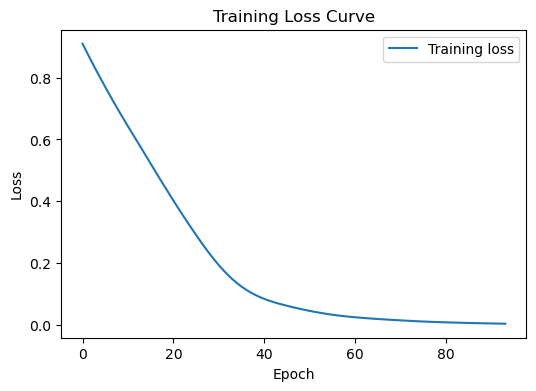

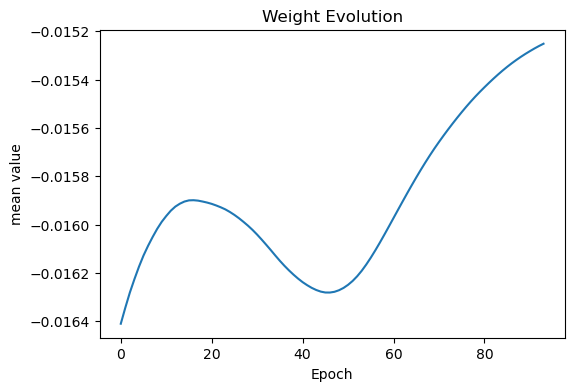

Computing bounds with margin 0.1.
Bounds per feature: [(-0.1, 1.08594538963311), (-0.09658050051593539, 1.073979787491971), (-0.1, 1.098885496855836), (-0.1, 1.002985774748292), (-0.09035112200825415, 1.086901999632929), (-0.07788659312394111, 1.0902438143772586), (-0.06409112383045615, 1.092914494924961), (-0.05804393054297677, 1.0887551042522277)]
Using 8 dimensions.
Points before downsampling: 39062500000000
Points after downsampling: 65536
Final grid shape: (65536, 8)
Filtering grid using mode: knn
Grid shape before filtering: (65536, 8)
Filtered 920 candidates near decision boundary (|margin| < 0.2)
Excluded 64616 candidates from consideration
Final grid shape: (920, 8)
Filtered grid shape: (920, 8)
Computing acquisition for method: PI
Computing acquisition for method: PI
Computing acquisition for method: PI
Computing acquisition for method: EI
Computing acquisition for method: EI
Computing acquisition for method: EI
Computing acquisition for method: UCB
Computing acquisition for 

In [7]:
X_grid_filtered, mean, bounds, best, query_results = sweep_hyperparameters_NNtrain(X, y, apply_scaling=True, filter_mode='knn')

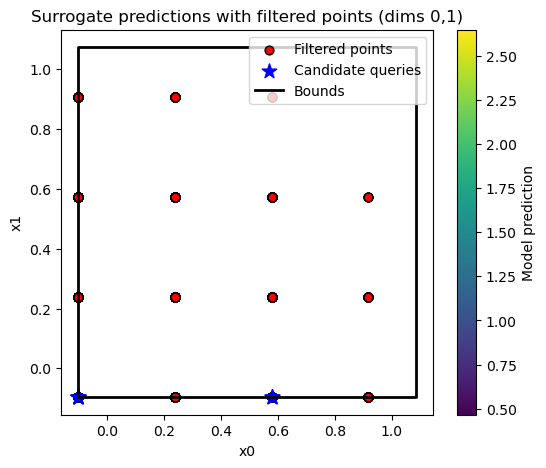

In [8]:
candidates, labels = extract_candidates_and_labels(query_results, include_score=True)

plot_surrogate_generic(X_grid_filtered, mean, 
                       X_filtered=X_grid_filtered, bounds=bounds, candidates=candidates, candidate_labels=None,
                       title="Surrogate predictions with filtered points")


In [9]:
print("Best Hyperparameter Configuration:")
print(best)

Best Hyperparameter Configuration:
{'method': 'UCB', 'xi': None, 'kappa': 3.0, 'x': array([ 0.57768308, -0.0965805 , -0.1       , -0.1       ,  0.91872298,
        0.92336804, -0.06409112, -0.05804393]), 'score': 6.314058315646151, 'dim': 8}


In [10]:
#add points to dataframe
#print(df)
add_points_to_df(df_sorted, query_results)
pd.set_option('display.max_rows', None)
print(df_sorted)

    hype-para-1  hype-para-2  hype-para-3  hype-para-4  hype-para-5  hype-para-6  hype-para-7  hype-para-8    output  source
41     0.121212     0.121212     0.000000     0.000000     0.363636     0.727273     0.484849     0.848484  9.609759  week-2
14     0.056447     0.065956     0.022929     0.038786     0.403935     0.801055     0.488307     0.893085  9.598482    file
42     0.043751     0.045306     0.045319     0.033695     0.337741     0.771663     0.496881     0.775992  9.587655  week-3
40     0.000000     0.125000     0.000000     0.000000     0.375000     0.750000     0.500000     0.875000  9.565800  week-1
26     0.192640     0.630677     0.416796     0.490529     0.796086     0.654567     0.276241     0.295518  9.344274    file
39     0.481245     0.102461     0.219486     0.677322     0.247509     0.244341     0.163825     0.715962  9.183005    file
22     0.145120     0.119328     0.420888     0.387609     0.155423     0.875172     0.510560     0.728611  9.141639    file


/var/folders/d6/s3jc1rb17y1411yjy8r6jlf80000gn/T/ipykernel_52230/923837372.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('tab10', len(other_cols))


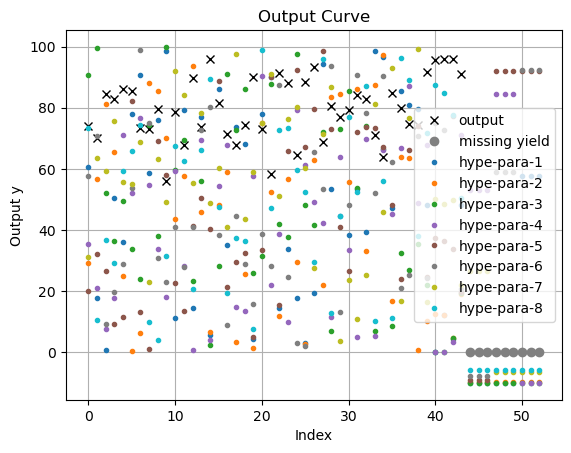

In [16]:
plot_output_points(df_sorted, scale_factor=100.0, yield_scale_factor=10.0, nan_marker='o')